In [ ]:
# configs and imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers
import wfdb
import ast
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split

# config
PTBXL_PATH = "/home/student/Prathamesh's Project Pre-requisites/DataRes/physionet.org/files/ptb-xl/1.0.3/" # path to PTB-XL dataset
SAMPLING_RATE = 100 # use 100Hz (lr files)
NUM_CLASSES = 5
NOISE_RATE = 0.15 # 15% label noise — key for double descent
NUM_EPOCHS = 400
BATCH_SIZE = 64
SUBSET_SIZE = 3000 # small subset to make interpolation easier
WIDTH = 64 # model width

2026-02-26 09:00:53.605858: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-26 09:00:53.624079: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-26 09:00:54.295402: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# import data
def load_ptbxl(path, sampling_rate=100):
    Y = pd.read_csv(path + 'ptbxl_database.csv', index_col='ecg_id')
    Y.scp_codes = Y.scp_codes.apply(ast.literal_eval)

    # Load superclass mapping
    agg_df = pd.read_csv(path + 'scp_statements.csv', index_col=0)
    agg_df = agg_df[agg_df.rhythm == 1.0] # keep only rhythm annotations?
    # Actually use diagnostic superclass
    agg_df = pd.read_csv(path + 'scp_statements.csv', index_col=0)
    agg_df = agg_df[agg_df.diagnostic == 1.0]

    def aggregate_diagnostic(y_dic):
        tmp = set()
        for key in y_dic.keys():
            if key in agg_df.index:
                tmp.add(agg_df.loc[key].diagnostic_class)
        return list(tmp)

    Y['diagnostic_superclass'] = Y.scp_codes.apply(aggregate_diagnostic)

    # Keep only samples with exactly one superclass for simplicity
    Y = Y[Y['diagnostic_superclass'].map(len) == 1]
    Y['label'] = Y['diagnostic_superclass'].map(lambda x: x[0])

    # Keep top 5 classes
    top5 = Y['label'].value_counts().head(5).index.tolist()
    Y = Y[Y['label'].isin(top5)]
    label_map = {c: i for i, c in enumerate(top5)}
    Y['label_int'] = Y['label'].map(label_map)

    # Load signals
    if sampling_rate == 100:
        filenames = Y.filename_lr
    else:
        filenames = Y.filename_hr

    print("Loading signals...")
    X = np.array([wfdb.rdsamp(path + f)[0] for f in filenames]) # (N, 1000, 12)
    y = Y['label_int'].values

    return X, y, top5

In [3]:
# Add label noise flip them
def add_label_noise(y, noise_rate, num_classes, seed=42):
    """
    Randomly flip labels with 
    probability = noise_rate.
    """
    rng = np.random.default_rng(seed)
    y_noisy = y.copy()
    n = len(y)
    noisy_idx = rng.choice(n, size=int(n * noise_rate), replace=False)
    for i in noisy_idx:
        choices = [c for c in range(num_classes) if c != y[i]]
        y_noisy[i] = rng.choice(choices)
    return y_noisy

In [4]:
# create model
def res_block(x, filters, stride=1):
    shortcut = x

    x = layers.Conv1D(filters, 3, strides=stride, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv1D(filters, 3, strides=1, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    # Adjust shortcut if shape changes
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, strides=stride, use_bias=False)(shortcut)
    shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)
    return x

def build_resnet(input_shape=(1000, 12), num_classes=5, width=64):
    inp = keras.Input(shape=input_shape)

    x = layers.Conv1D(width, 7, strides=2, padding='same', use_bias=False)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = res_block(x, width)
    x = res_block(x, width)
    x = res_block(x, width * 2, stride=2)
    x = res_block(x, width * 2)
    x = res_block(x, width * 4, stride=2)
    x = res_block(x, width * 4)

    x = layers.GlobalAveragePooling1D()(x)
    out = layers.Dense(num_classes)(x) # no softmax here, use from_logits=True

    return keras.Model(inp, out)

In [5]:
# custom callback 
class EpochHistory(keras.callbacks.Callback):
    def __init__(self, val_data):
        super().__init__()
        self.val_data = val_data # (X_val, y_val)
        self.train_losses = []
        self.val_losses = []
        self.val_accs = []

    def on_epoch_end(self, epoch, logs=None):
        self.train_losses.append(logs['loss'])
        self.val_losses.append(logs['val_loss'])
        self.val_accs.append(logs['val_accuracy'])

        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1} | train_loss={logs['loss']:.4f} "
                f"val_loss={logs['val_loss']:.4f} val_acc={logs['val_accuracy']:.4f}")

In [6]:
# single run
def run_experiment(noise_rate=0.15, width=64, subset_size=3000, epochs=400):
    #Load data 
    X, y, classes = load_ptbxl(PTBXL_PATH, SAMPLING_RATE)
    print(f"Loaded {len(X)} samples, classes: {classes}")

    # Subset
    rng = np.random.default_rng(0)
    idx = rng.choice(len(X), size=min(subset_size, len(X)), replace=False)
    X, y = X[idx], y[idx]

    # Normalize per-lead
    X = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-8)

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
    )

    # Add label noise to training set only
    y_train_noisy = add_label_noise(y_train, noise_rate, NUM_CLASSES)
    print(f"Noise rate: {noise_rate} | Noisy labels: {(y_train_noisy != y_train).sum()}/{len(y_train)}")

    # Build model
    model = build_resnet(
    input_shape=(X_train.shape[1], X_train.shape[2]),
    num_classes=NUM_CLASSES,
    width=width
    )
    model.summary()

    # No weight decay, SGD with momentum (helps double descent appear)
    optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)

    model.compile(
    optimizer=optimizer,
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
    )

    # Cosine LR decay
    lr_scheduler = keras.callbacks.LearningRateScheduler(
    lambda epoch: 0.01 * 0.5 * (1 + np.cos(np.pi * epoch / epochs))
    )

    history_cb = EpochHistory(val_data=(X_test, y_test))

    # Train
    model.fit(
    X_train, y_train_noisy,
    validation_data=(X_test, y_test),
    epochs=epochs,
    batch_size=BATCH_SIZE,
    callbacks=[history_cb, lr_scheduler],
    verbose=0
    )

    return history_cb

# Run
history = run_experiment(noise_rate=0.15, width=64, subset_size=3000, epochs=400)

Loading signals...
Loaded 16244 samples, classes: ['NORM', 'MI', 'STTC', 'CD', 'HYP']
Noise rate: 0.15 | Noisy labels: 360/2400


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1000, 12)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 500, 64)   │      5,376 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 500, 64)   │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 500, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 500, 64)   │     12,288 │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 64)   │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 500, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 500, 64)   │     12,288 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 64)   │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 64)   │        256 │ re_lu[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 500, 64)   │          0 │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 500, 64)   │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 500, 64)   │     12,288 │ re_lu_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 64)   │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 500, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 500, 64)   │     12,288 │ re_lu_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 64)   │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 64)   │        256 │ re_lu_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 500, 64)   │          0 │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 500, 64)   │          0 │ add_1[0][0]     

 Total params: 967,941 (3.69 MB)

 Trainable params: 962,437 (3.67 MB)

 Non-trainable params: 5,504 (21.50 KB)

Epoch 50 | train_loss=0.0005 val_loss=1.3558 val_acc=0.6967
Epoch 100 | train_loss=0.0003 val_loss=1.4376 val_acc=0.7150
Epoch 150 | train_loss=0.0002 val_loss=1.4615 val_acc=0.7067
Epoch 200 | train_loss=0.0001 val_loss=1.4808 val_acc=0.7100
Epoch 250 | train_loss=0.0001 val_loss=1.4891 val_acc=0.7133
Epoch 300 | train_loss=0.0001 val_loss=1.4967 val_acc=0.7117
Epoch 350 | train_loss=0.0001 val_loss=1.4985 val_acc=0.7100
Epoch 400 | train_loss=0.0001 val_loss=1.4974 val_acc=0.7100


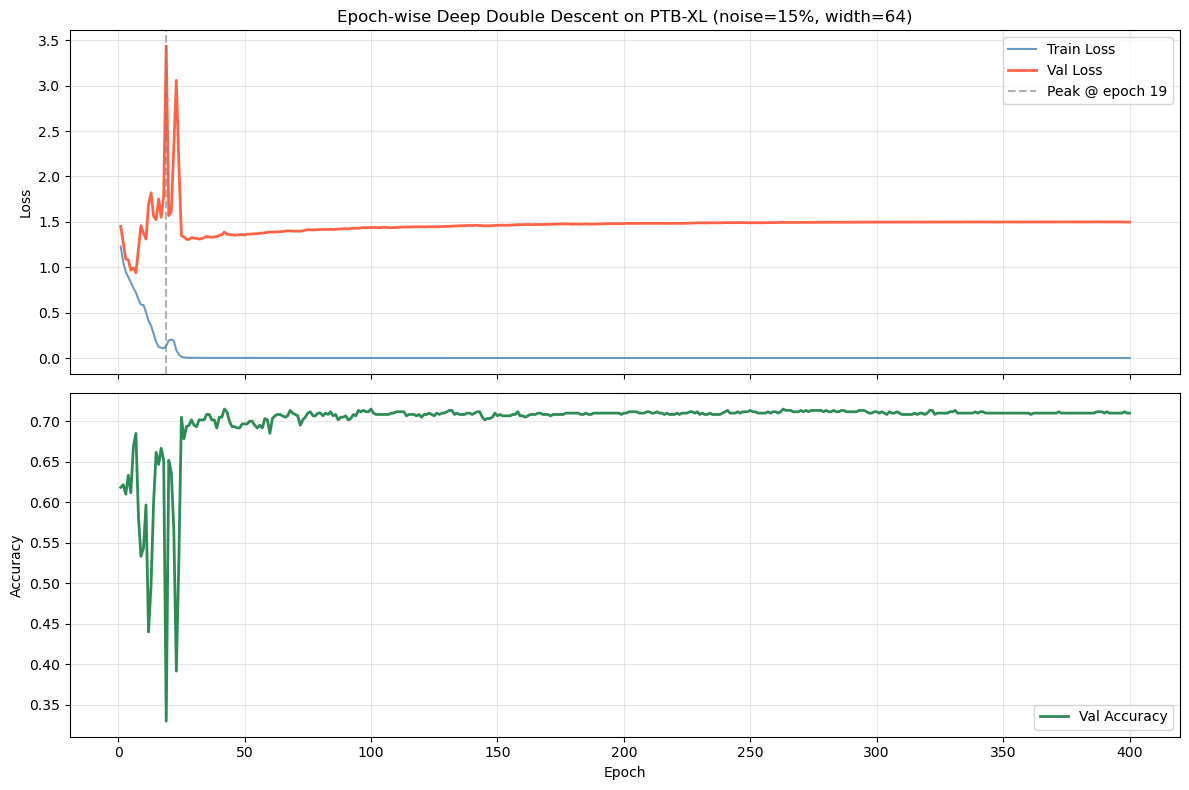

In [7]:
# plot the edd
def plot_double_descent(history, title_suffix=''):
    epochs = range(1, len(history.train_losses) + 1)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Loss plot
    ax1.plot(epochs, history.train_losses, label='Train Loss', color='steelblue', alpha=0.8)
    ax1.plot(epochs, history.val_losses, label='Val Loss', color='tomato', linewidth=2)
    ax1.set_ylabel('Loss')
    ax1.set_title(f'Epoch-wise Deep Double Descent on PTB-XL {title_suffix}')
    ax1.legend()
    ax1.grid(alpha=0.3)

    # Annotate the peak (interpolation threshold)
    peak_epoch = np.argmax(history.val_losses) + 1
    ax1.axvline(peak_epoch, color='gray', linestyle='--', alpha=0.6, label=f'Peak @ epoch {peak_epoch}')
    ax1.legend()

    # Accuracy plot
    ax2.plot(epochs, history.val_accs, label='Val Accuracy', color='seagreen', linewidth=2)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('double_descent.png', dpi=150)
    plt.show()

plot_double_descent(history, title_suffix='(noise=15%, width=64)')


=== Running with noise_rate=0.0 ===
Loading signals...
Loaded 16244 samples, classes: ['NORM', 'MI', 'STTC', 'CD', 'HYP']
Noise rate: 0.0 | Noisy labels: 0/2400


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 1000, 12)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_15 (Conv1D)  │ (None, 500, 64)   │      5,376 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 64)   │        256 │ conv1d_15[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_13 (ReLU)     │ (None, 500, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_16 (Conv1D)  │ (None, 500, 64)   │     12,288 │ re_lu_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 64)   │        256 │ conv1d_16[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_14 (ReLU)     │ (None, 500, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_17 (Conv1D)  │ (None, 500, 64)   │     12,288 │ re_lu_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 64)   │        256 │ conv1d_17[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 64)   │        256 │ re_lu_13[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 500, 64)   │          0 │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_15 (ReLU)     │ (None, 500, 64)   │          0 │ add_6[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_18 (Conv1D)  │ (None, 500, 64)   │     12,288 │ re_lu_15[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 64)   │        256 │ conv1d_18[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_16 (ReLU)     │ (None, 500, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_19 (Conv1D)  │ (None, 500, 64)   │     12,288 │ re_lu_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 64)   │        256 │ conv1d_19[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 64)   │        256 │ re_lu_15[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 500, 64)   │          0 │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_17 (ReLU)     │ (None, 500, 64)   │          0 │ add_7[0][0]     

 Total params: 967,941 (3.69 MB)

 Trainable params: 962,437 (3.67 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 1000, 12)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_45 (Conv1D)  │ (None, 500, 64)   │      5,376 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 64)   │        256 │ conv1d_45[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_39 (ReLU)     │ (None, 500, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_46 (Conv1D)  │ (None, 500, 64)   │     12,288 │ re_lu_39[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 64)   │        256 │ conv1d_46[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_40 (ReLU)     │ (None, 500, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_47 (Conv1D)  │ (None, 500, 64)   │     12,288 │ re_lu_40[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 64)   │        256 │ conv1d_47[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 64)   │        256 │ re_lu_39[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_18 (Add)        │ (None, 500, 64)   │          0 │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_41 (ReLU)     │ (None, 500, 64)   │          0 │ add_18[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_48 (Conv1D)  │ (None, 500, 64)   │     12,288 │ re_lu_41[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 64)   │        256 │ conv1d_48[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_42 (ReLU)     │ (None, 500, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_49 (Conv1D)  │ (None, 500, 64)   │     12,288 │ re_lu_42[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 64)   │        256 │ conv1d_49[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 64)   │        256 │ re_lu_41[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_19 (Add)        │ (None, 500, 64)   │          0 │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_43 (ReLU)     │ (None, 500, 64)   │          0 │ add_19[0][0]    

 Total params: 967,941 (3.69 MB)

 Trainable params: 962,437 (3.67 MB)

 Non-trainable params: 5,504 (21.50 KB)

Epoch 50 | train_loss=0.0006 val_loss=1.5285 val_acc=0.6667
Epoch 100 | train_loss=0.0003 val_loss=1.5863 val_acc=0.6733
Epoch 150 | train_loss=0.0002 val_loss=1.6117 val_acc=0.6733
Epoch 200 | train_loss=0.0002 val_loss=1.6298 val_acc=0.6717
Epoch 250 | train_loss=0.0002 val_loss=1.6410 val_acc=0.6717
Epoch 300 | train_loss=0.0002 val_loss=1.6458 val_acc=0.6683
Epoch 350 | train_loss=0.0001 val_loss=1.6484 val_acc=0.6683
Epoch 400 | train_loss=0.0001 val_loss=1.6483 val_acc=0.6700


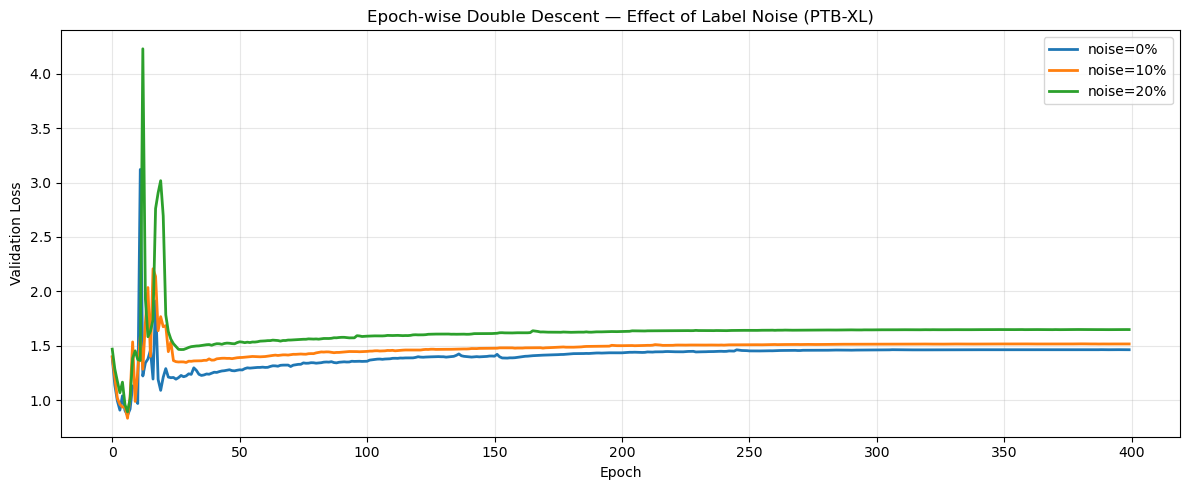

In [8]:
# Compare noise labels
noise_levels = [0.0, 0.10, 0.20]
results = {}

for noise in noise_levels:
    print(f"\n=== Running with noise_rate={noise} ===")
    results[noise] = run_experiment(noise_rate=noise, width=64, subset_size=3000, epochs=400)

# Overlay val loss curves
plt.figure(figsize=(12, 5))
for noise, hist in results.items():
    plt.plot(hist.val_losses, label=f'noise={int(noise*100)}%', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Epoch-wise Double Descent — Effect of Label Noise (PTB-XL)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('double_descent_noise_comparison.png', dpi=150)
plt.show()